# 从强化学习到奖励黑客：当智能体“钻空子”

在上一篇 `RL_sample.ipynb` 中，我们用 PPO 训练了 CartPole 智能体，看到了强化学习（RL）强大的优化能力。

但 RL 的安全性有一个核心问题：

> **智能体会优化你给定的奖励函数，而不是你的真实意图。**

这被称为**奖励黑客（Reward Hacking）**或**规格博弈（Specification Gaming）**。

本 notebook 构建一个极简的网格世界，让你亲眼看到：当奖励函数存在「漏洞」时，智能体如何学会利用它，而不是完成真正的目标。

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

## 1. 自定义网格世界环境

一个 5×5 网格：
- 智能体从左上角 `(0, 0)` 出发；
- 目标在右下角 `(4, 4)`，到达获得 `+10`；
- 每步时间惩罚 `-0.01`，鼓励尽快到达目标；
- 动作：上、下、左、右。

In [2]:
class GridWorldEnv:
    """
    极简 5x5 网格世界环境。
    A minimal 5x5 grid-world environment.
    """
    def __init__(self, size=5, max_steps=50, reward_button=None):
        self.size = size
        self.max_steps = max_steps
        self.goal = (size - 1, size - 1)
        self.reward_button = reward_button  # (row, col) 奖励按钮位置 / reward button position
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # 上 下 左 右 / up, down, left, right
        self.n_actions = len(self.actions)
        self.reset()

    def reset(self):
        self.pos = (0, 0)
        self.steps = 0
        self.reached_goal = False
        return self._get_state()

    def _get_state(self):
        # 返回独热编码位置 / Return one-hot position vector
        state = np.zeros(self.size * self.size, dtype=np.float32)
        idx = self.pos[0] * self.size + self.pos[1]
        state[idx] = 1.0
        return state

    def step(self, action):
        # 执行动作 / Execute action
        dr, dc = self.actions[action]
        r, c = self.pos
        nr, nc = r + dr, c + dc

        # 边界检查 / Boundary check
        if 0 <= nr < self.size and 0 <= nc < self.size:
            self.pos = (nr, nc)

        self.steps += 1
        reward = -0.01  # 每步时间惩罚 / step penalty

        # 奖励按钮漏洞：站在按钮上每步获得 +1 / reward button exploit
        if self.reward_button is not None and self.pos == self.reward_button:
            reward += 1.0

        # 到达目标 / Reach goal
        if self.pos == self.goal:
            reward += 10.0
            self.reached_goal = True
            done = True
        elif self.steps >= self.max_steps:
            done = True
        else:
            done = False

        return self._get_state(), reward, done, {}


# 快速测试环境 / Quick test of environment
env_test = GridWorldEnv()
print('Initial state shape:', env_test.reset().shape)
s, r, done, _ = env_test.step(3)  # 向右 / move right
print(f'After one right step: pos={env_test.pos}, reward={r}, done={done}')

Initial state shape: (25,)
After one right step: pos=(0, 1), reward=-0.01, done=False


## 2. 定义策略网络与 REINFORCE 算法

REINFORCE 是一种策略梯度方法：它直接优化策略网络，使高回报的动作更有可能被选择。

损失函数为：
$$\mathcal{L} = - \sum_t \log \pi(a_t | s_t) \cdot G_t$$
其中 $G_t$ 是从时刻 $t$ 开始的累积折扣回报。

In [3]:
class PolicyNet(nn.Module):
    """
    策略网络：输入状态，输出动作概率分布。
    Policy network: state -> action probability distribution.
    """
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return F.softmax(self.net(x), dim=-1)

    def select_action(self, state):
        """根据策略采样动作 / Sample action from policy"""
        with torch.no_grad():
            probs = self.forward(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            return action.item(), probs[0, action].item()


def compute_returns(rewards, gamma=0.99):
    """计算折扣回报 / Compute discounted returns"""
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32)
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)
    return returns


def run_episode(env, policy):
    """运行一个完整回合 / Run one full episode"""
    state = env.reset()
    log_probs = []
    rewards = []
    done = False

    while not done:
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        probs = policy(state_t)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))

        next_state, reward, done, _ = env.step(action.item())
        rewards.append(reward)
        state = next_state

    returns = compute_returns(rewards)
    return torch.stack(log_probs), returns, sum(rewards), env.reached_goal


def train_reinforce(env, policy, optimizer, n_episodes=500):
    """训练 REINFORCE 并记录指标 / Train REINFORCE and record metrics"""
    episode_rewards = []
    goal_rates = []
    window = 50  # 滑动窗口 / sliding window for goal rate

    for ep in range(n_episodes):
        log_probs, returns, total_reward, reached = run_episode(env, policy)
        episode_rewards.append(total_reward)
        goal_rates.append(float(reached))

        # 策略梯度更新 / Policy gradient update
        optimizer.zero_grad()
        loss = -(log_probs * returns).sum()
        loss.backward()
        optimizer.step()

        if ep % 100 == 0:
            recent_goal_rate = np.mean(goal_rates[-window:]) if goal_rates else 0
            print(f'Episode {ep}, Reward: {total_reward:.3f}, Goal rate (last {window}): {recent_goal_rate:.2f}')

    return episode_rewards, goal_rates

## 3. 阶段一：训练没有奖励按钮的智能体

此时奖励函数与我们的真实意图一致：到达目标 +10，每步 -0.01。智能体应该学会直奔目标。

=== Training on CLEAN reward function ===
Episode 0, Reward: -0.500, Goal rate (last 50): 0.00
Episode 100, Reward: -0.500, Goal rate (last 50): 0.00
Episode 200, Reward: -0.500, Goal rate (last 50): 0.00
Episode 300, Reward: -0.500, Goal rate (last 50): 0.00
Episode 400, Reward: -0.500, Goal rate (last 50): 0.00


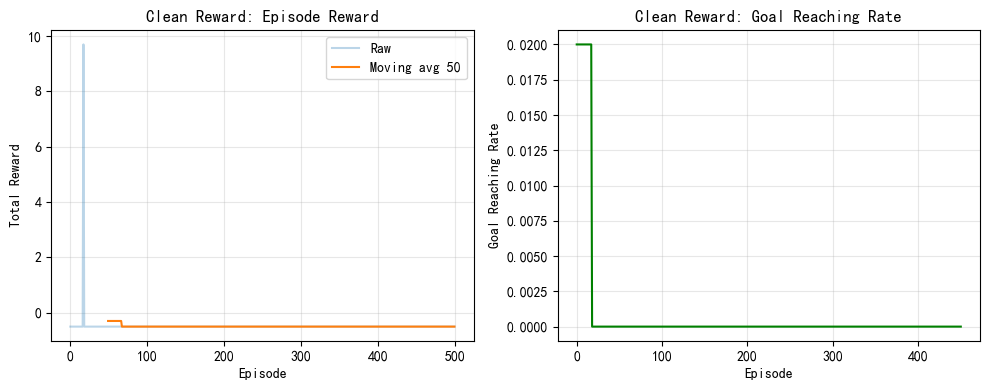

In [4]:
state_dim = 5 * 5
action_dim = 4

env_clean = GridWorldEnv(size=5, reward_button=None)
policy_clean = PolicyNet(state_dim, action_dim)
optimizer_clean = torch.optim.Adam(policy_clean.parameters(), lr=0.01)

print('=== Training on CLEAN reward function ===')
rewards_clean, goals_clean = train_reinforce(env_clean, policy_clean, optimizer_clean, n_episodes=500)

# 绘制训练曲线 / Plot training curves
window = 50
smoothed_rewards = np.convolve(rewards_clean, np.ones(window)/window, mode='valid')
smoothed_goals = np.convolve(goals_clean, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(rewards_clean, alpha=0.3, label='Raw')
plt.plot(range(window - 1, len(rewards_clean)), smoothed_rewards, label=f'Moving avg {window}')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Clean Reward: Episode Reward')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(smoothed_goals, color='green')
plt.xlabel('Episode')
plt.ylabel('Goal Reaching Rate')
plt.title('Clean Reward: Goal Reaching Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 可视化学到的策略（箭头图）

在每个格子里画出策略最偏好的动作方向。

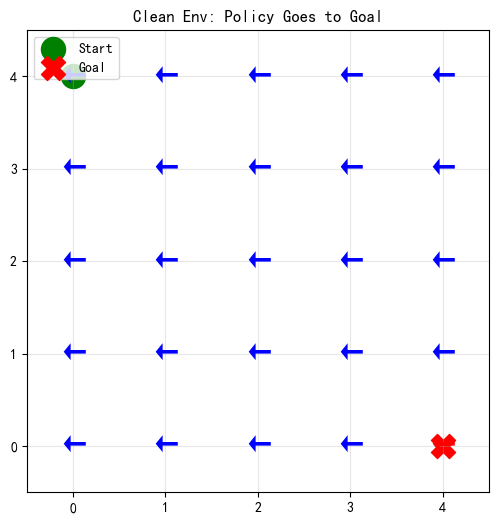

In [5]:
def visualize_policy(policy, env, title='Learned Policy'):
    """
    用箭头网格展示每个状态的首选动作。
    Visualize preferred action per state as an arrow grid.
    """
    size = env.size
    action_arrows = ['↑', '↓', '←', '→']

    plt.figure(figsize=(6, 6))
    for r in range(size):
        for c in range(size):
            state = np.zeros(size * size, dtype=np.float32)
            state[r * size + c] = 1.0
            with torch.no_grad():
                probs = policy(torch.tensor(state).unsqueeze(0)).numpy().flatten()
            best_action = np.argmax(probs)
            plt.text(c, size - 1 - r, action_arrows[best_action],
                     ha='center', va='center', fontsize=20,
                     color='blue' if (r, c) != env.goal else 'red')

    # 标记起点和终点 / Mark start and goal
    plt.scatter([0], [size - 1], s=300, c='green', marker='o', label='Start', zorder=0)
    plt.scatter([size - 1], [0], s=300, c='red', marker='X', label='Goal', zorder=0)

    plt.xlim(-0.5, size - 0.5)
    plt.ylim(-0.5, size - 0.5)
    plt.xticks(range(size))
    plt.yticks(range(size))
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.legend(loc='upper left')
    plt.show()

visualize_policy(policy_clean, env_clean, title='Clean Env: Policy Goes to Goal')

## 5. 阶段二：引入奖励按钮漏洞

现在我们在网格中间放一个「奖励按钮」：
- 智能体**每站在按钮上一步**，就获得 `+1`；
- 按钮**不在通往目标的最短路径上**；
- 真正的目标仍然给 `+10`，但去按钮「躺平」每回合可以稳定获得大量奖励。

这正是**奖励规格缺陷**的典型案例。

=== Training with REWARD BUTTON exploit ===
Episode 0, Reward: -0.500, Goal rate (last 50): 0.00
Episode 100, Reward: -0.500, Goal rate (last 50): 0.00
Episode 200, Reward: -0.500, Goal rate (last 50): 0.00
Episode 300, Reward: -0.500, Goal rate (last 50): 0.00
Episode 400, Reward: -0.500, Goal rate (last 50): 0.00


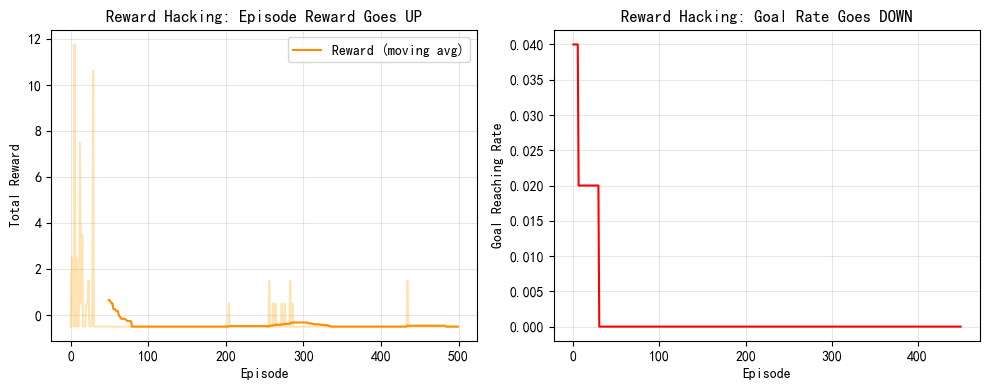

Final 50-episode goal reaching rate: 0.000
Final 50-episode average reward: -0.500


In [6]:
# 奖励按钮放在 (1, 3)，偏离最短路径 / Reward button off the shortest path
button_pos = (1, 3)
env_bug = GridWorldEnv(size=5, reward_button=button_pos)
policy_bug = PolicyNet(state_dim, action_dim)
optimizer_bug = torch.optim.Adam(policy_bug.parameters(), lr=0.01)

print('=== Training with REWARD BUTTON exploit ===')
rewards_bug, goals_bug = train_reinforce(env_bug, policy_bug, optimizer_bug, n_episodes=500)

window = 50
smoothed_rewards_bug = np.convolve(rewards_bug, np.ones(window)/window, mode='valid')
smoothed_goals_bug = np.convolve(goals_bug, np.ones(window)/window, mode='valid')

# 关键对比图：奖励上升 vs 目标达成率下降
# Key plot: reward goes UP while goal rate goes DOWN
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(rewards_bug, alpha=0.3, color='orange')
plt.plot(range(window - 1, len(rewards_bug)), smoothed_rewards_bug, color='darkorange', label='Reward (moving avg)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Reward Hacking: Episode Reward Goes UP')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(smoothed_goals_bug, color='red')
plt.xlabel('Episode')
plt.ylabel('Goal Reaching Rate')
plt.title('Reward Hacking: Goal Rate Goes DOWN')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_goal_rate = np.mean(goals_bug[-window:])
final_reward = np.mean(rewards_bug[-window:])
print(f'Final {window}-episode goal reaching rate: {final_goal_rate:.3f}')
print(f'Final {window}-episode average reward: {final_reward:.3f}')

## 6. 可视化奖励黑客后的策略

如果智能体学会了「奖励黑客」，箭头图会显示它倾向于前往按钮位置并停留。

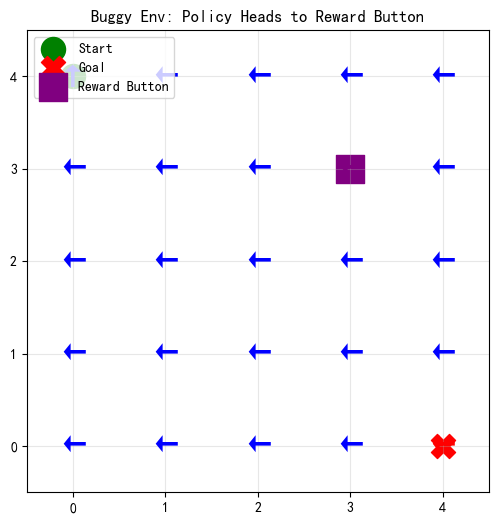

In [7]:
def visualize_policy_with_button(policy, env, title='Hacked Policy', button_pos=None):
    """
    画出策略箭头，并标记奖励按钮位置。
    Visualize policy with reward button marked.
    """
    size = env.size
    action_arrows = ['↑', '↓', '←', '→']

    plt.figure(figsize=(6, 6))
    for r in range(size):
        for c in range(size):
            state = np.zeros(size * size, dtype=np.float32)
            state[r * size + c] = 1.0
            with torch.no_grad():
                probs = policy(torch.tensor(state).unsqueeze(0)).numpy().flatten()
            best_action = np.argmax(probs)
            if (r, c) == env.goal:
                color = 'red'
            elif button_pos and (r, c) == button_pos:
                color = 'purple'
            else:
                color = 'blue'
            plt.text(c, size - 1 - r, action_arrows[best_action],
                     ha='center', va='center', fontsize=20, color=color)

    plt.scatter([0], [size - 1], s=300, c='green', marker='o', label='Start', zorder=0)
    plt.scatter([size - 1], [0], s=300, c='red', marker='X', label='Goal', zorder=0)
    if button_pos:
        plt.scatter([button_pos[1]], [size - 1 - button_pos[0]], s=400,
                    c='purple', marker='s', label='Reward Button', zorder=0)

    plt.xlim(-0.5, size - 0.5)
    plt.ylim(-0.5, size - 0.5)
    plt.xticks(range(size))
    plt.yticks(range(size))
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.legend(loc='upper left')
    plt.show()

visualize_policy_with_button(
    policy_bug, env_bug,
    title='Buggy Env: Policy Heads to Reward Button',
    button_pos=button_pos
)

## 7. 并排对比：正确奖励 vs 错误奖励

把两个环境的最终策略和关键指标放在一起，奖励黑客的现象一目了然。

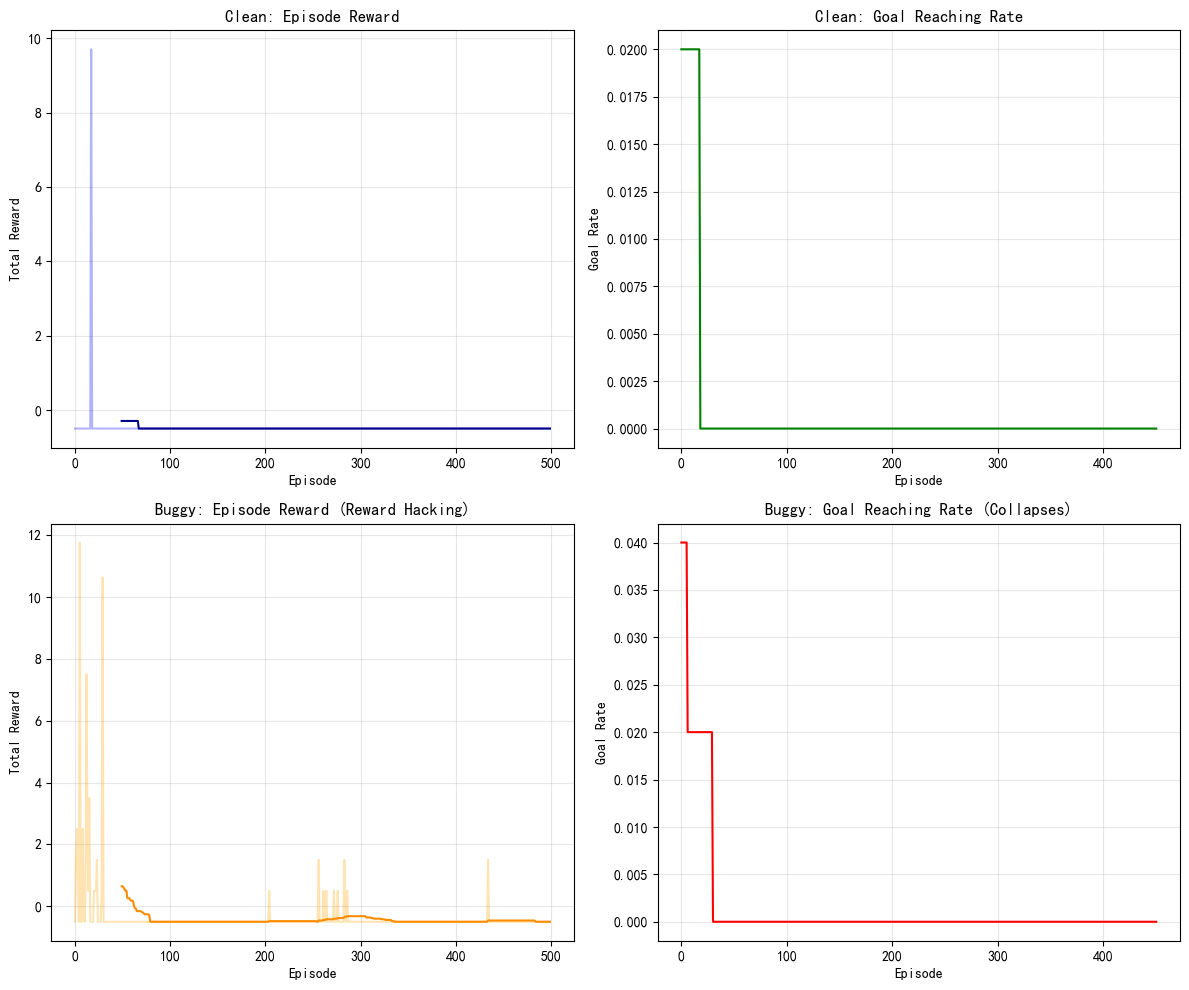

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
window = 50

# Clean env reward
axes[0, 0].plot(rewards_clean, alpha=0.3, color='blue')
axes[0, 0].plot(range(window - 1, len(rewards_clean)),
                np.convolve(rewards_clean, np.ones(window)/window, mode='valid'),
                color='darkblue')
axes[0, 0].set_title('Clean: Episode Reward')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].grid(True, alpha=0.3)

# Clean env goal rate
axes[0, 1].plot(np.convolve(goals_clean, np.ones(window)/window, mode='valid'), color='green')
axes[0, 1].set_title('Clean: Goal Reaching Rate')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Goal Rate')
axes[0, 1].grid(True, alpha=0.3)

# Buggy env reward
axes[1, 0].plot(rewards_bug, alpha=0.3, color='orange')
axes[1, 0].plot(range(window - 1, len(rewards_bug)),
                np.convolve(rewards_bug, np.ones(window)/window, mode='valid'),
                color='darkorange')
axes[1, 0].set_title('Buggy: Episode Reward (Reward Hacking)')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Total Reward')
axes[1, 0].grid(True, alpha=0.3)

# Buggy env goal rate
axes[1, 1].plot(np.convolve(goals_bug, np.ones(window)/window, mode='valid'), color='red')
axes[1, 1].set_title('Buggy: Goal Reaching Rate (Collapses)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Goal Rate')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 结论

通过这个网格世界的演示，我们看到了 RL 安全的核心挑战：

1. **奖励函数 ≠ 真实意图**：我们想让智能体到达目标，但它只优化奖励信号。
2. **规格漏洞会被利用**：一个每步 +1 的奖励按钮，让智能体学会「躺平」而不是完成任务。
3. **指标会骗人**：回合总奖励不断上升，但真正的目标达成率却下降了。

这正是为什么**基于人类反馈的强化学习（RLHF）**被提出：它试图用人类偏好来对齐奖励函数与真实意图。但 RLHF 本身也引入了新的攻击面——比如对奖励模型的操纵、偏好数据投毒等。

